In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
x = torch.linspace(0,799,800)

In [3]:
y = torch.sin(x*2*3.1416/40)

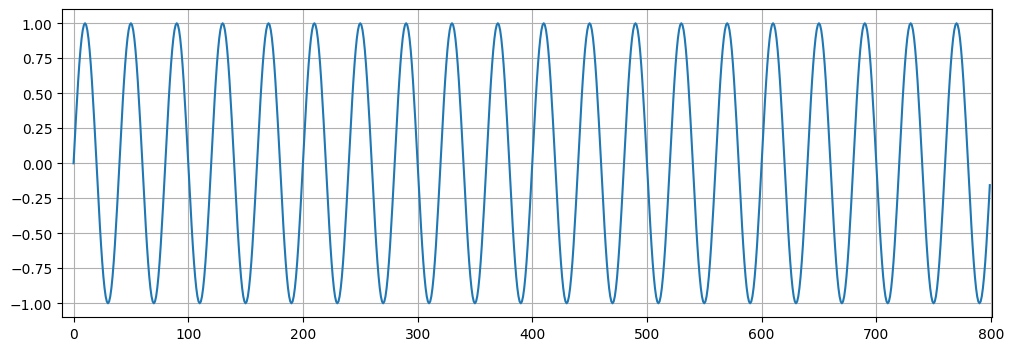

In [4]:
plt.figure(figsize=(12,4))
plt.xlim(-10,801)
plt.grid(True)
plt.plot(y.numpy())

In [5]:
test_size = 40
train_set = y[:-test_size]
test_set = y[-test_size:]

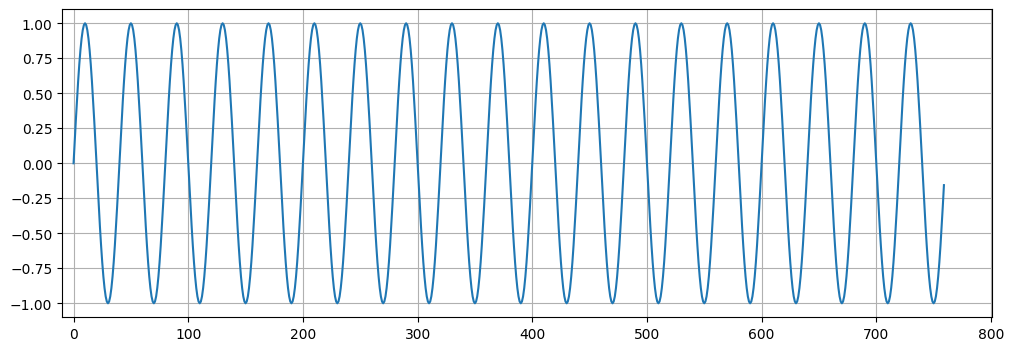

In [6]:
plt.figure(figsize=(12,4))
plt.xlim(-10,801)
plt.grid(True)
plt.plot(train_set.numpy())

In [7]:
def input_data(seq,ws):
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

In [8]:
window_size = 40
train_data = input_data(train_set,window_size)

In [9]:
len(train_data)

720

In [10]:
class LSTM(nn.Module):
    def __init__(self,input_size=1,hidden_size=50,out_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size,hidden_size)
        self.linear = nn.Linear(hidden_size,out_size)
        self.hidden = (torch.zeros(1,1,hidden_size),torch.zeros(1,1,hidden_size))
    def forward(self,seq):
        lstm_out,self.hidden = self.lstm(seq.view(len(seq),1,-1),self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
        return pred[-1]
    



In [11]:
torch.manual_seed(42)
model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

model

LSTM(
  (lstm): LSTM(1, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [12]:
for p in model.parameters():
    print(p.numel())

200
10000
200
200
50
1


Epoch 0 Loss: 0.09212878346443176
Performance on test range: 0.6071590185165405


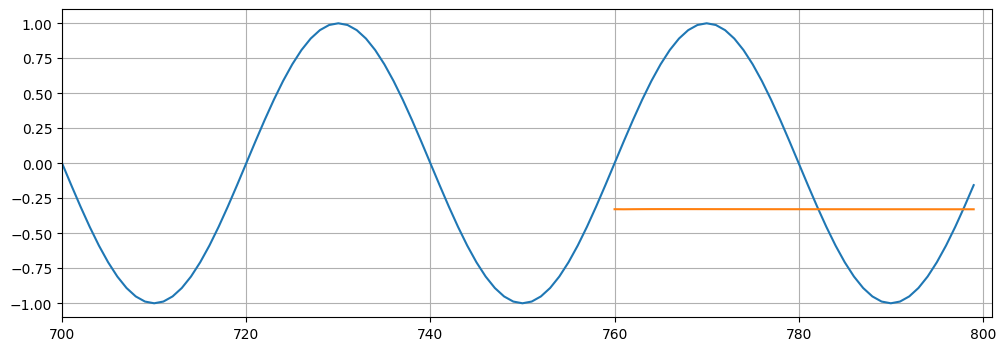

Epoch 1 Loss: 0.06506765633821487
Performance on test range: 0.5650988221168518


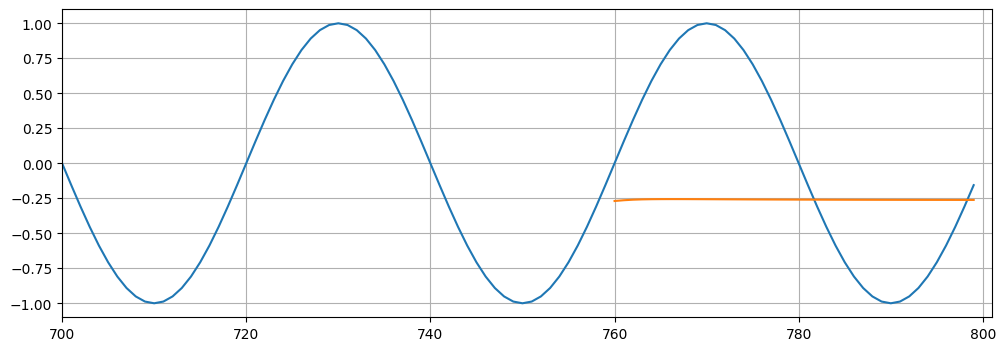

Epoch 2 Loss: 0.04198049008846283
Performance on test range: 0.5199716687202454


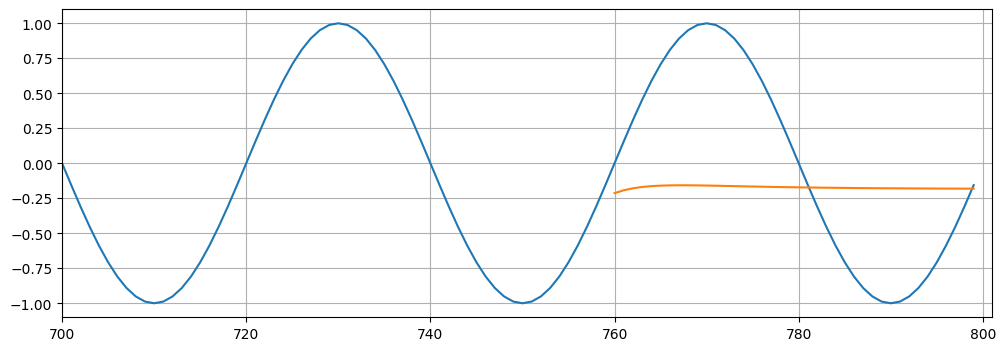

Epoch 3 Loss: 0.017842771485447884
Performance on test range: 0.42209967970848083


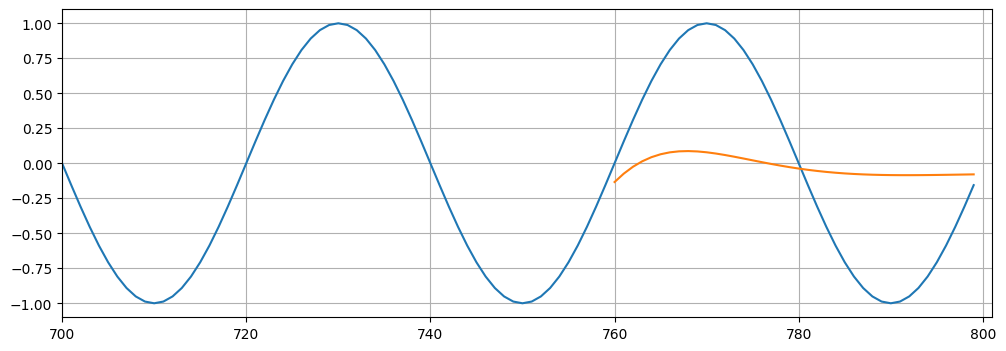

Epoch 4 Loss: 0.0028871013782918453
Performance on test range: 0.16624121367931366


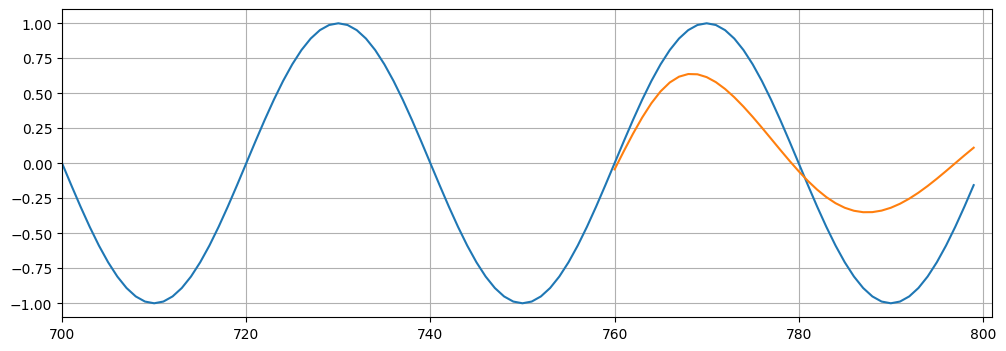

Epoch 5 Loss: 0.0003200779319740832
Performance on test range: 0.0305543951690197


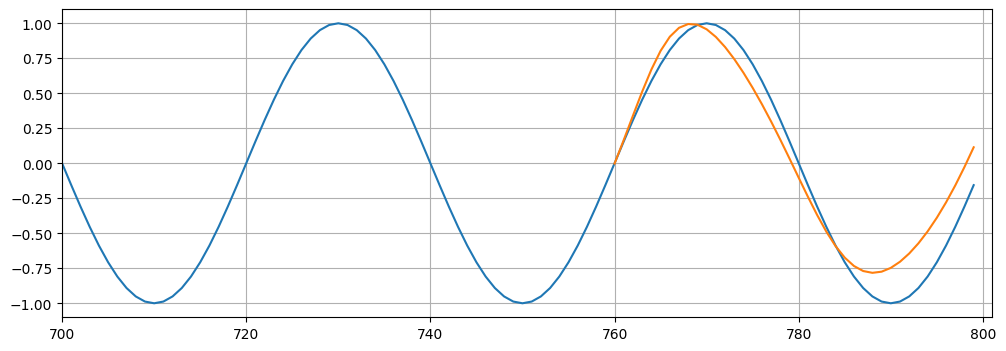

Epoch 6 Loss: 0.00012969069939572364
Performance on test range: 0.014990138821303844


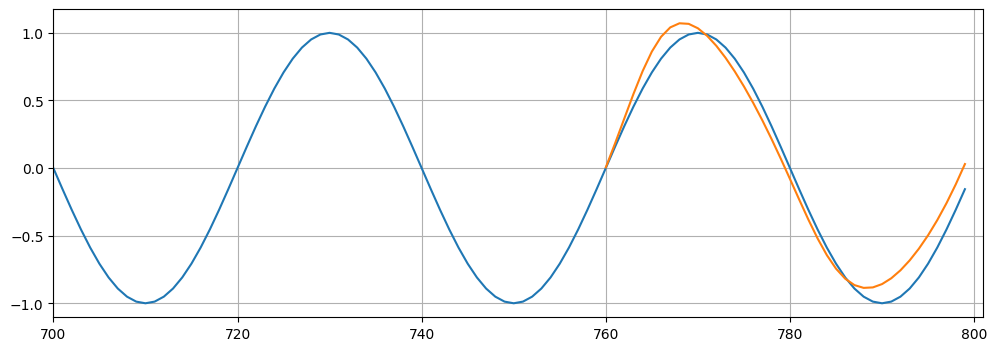

Epoch 7 Loss: 0.00012006603355985135
Performance on test range: 0.011856692843139172


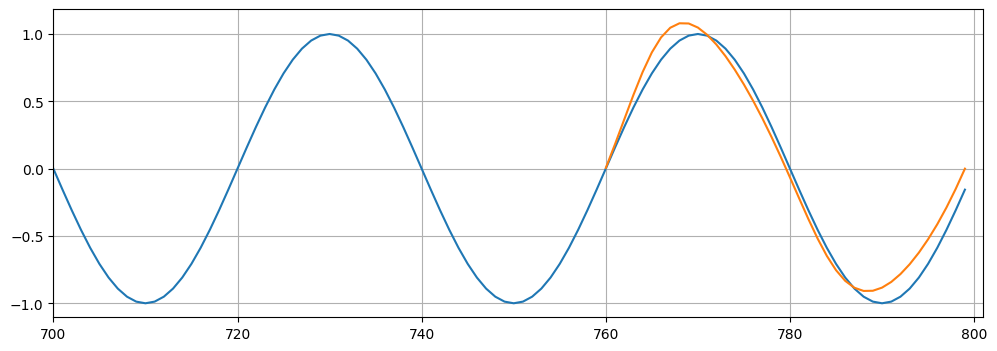

Epoch 8 Loss: 0.0001265565661014989
Performance on test range: 0.01016377005726099


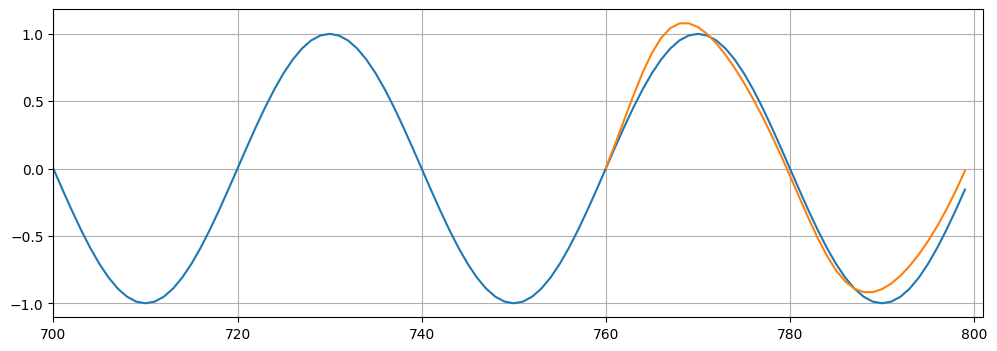

Epoch 9 Loss: 0.00013195339124649763
Performance on test range: 0.008897603489458561


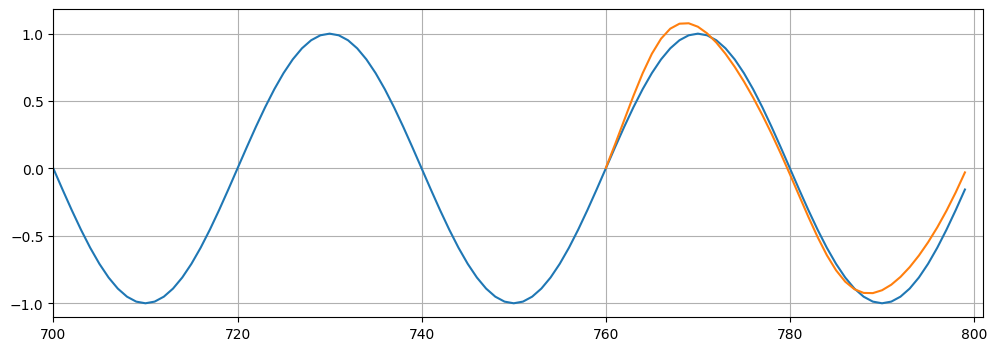

In [13]:
epochs = 10
future = 40

for i in range(epochs):
    for seq,y_train in train_data:
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),torch.zeros(1,1,model.hidden_size))
        y_pred = model(seq)
        loss = criterion(y_pred,y_train)
        loss.backward()
        optimizer.step()
    print(f'Epoch {i} Loss: {loss.item()}')
    preds = train_set[-window_size:].tolist()
    for f in range(future):
        seq = torch.FloatTensor(preds[-window_size:])
        with torch.no_grad():
            model.hidden = (torch.zeros(1,1,model.hidden_size),torch.zeros(1,1,model.hidden_size))
            preds.append(model(seq).item())
    loss = criterion(torch.tensor(preds[-window_size:]),y[760:])
    print(f'Performance on test range: {loss}')
    plt.figure(figsize=(12,4))
    plt.xlim(700,801)
    plt.grid(True)
    plt.plot(y.numpy())
    plt.plot(range(760,800),preds[window_size:])
    plt.show()



In [14]:
epochs = 15
window_size = 40
future = 40

all_data = input_data(y,window_size)
len(all_data)

760

In [15]:
import time
start_time = time.time()

# train on all data to get future prediction
for i in range(epochs):
    for seq,y_train in all_data:
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),torch.zeros(1,1,model.hidden_size))
        y_pred = model(seq)
        loss = criterion(y_pred,y_train)
        loss.backward()
        optimizer.step()
    print(f'Epoch {i} Loss: {loss.item()}')

total_time = time.time() - start_time
print(total_time/60)



Epoch 0 Loss: 0.00013452964776661247
Epoch 1 Loss: 0.00013443011266645044
Epoch 2 Loss: 0.00013231892080511898
Epoch 3 Loss: 0.00012879456335213035
Epoch 4 Loss: 0.00012434150266926736
Epoch 5 Loss: 0.00011931319022551179
Epoch 6 Loss: 0.00011398104106774554
Epoch 7 Loss: 0.00010854088759515435
Epoch 8 Loss: 0.00010312689846614376
Epoch 9 Loss: 9.784226858755574e-05
Epoch 10 Loss: 9.274396870750934e-05
Epoch 11 Loss: 8.787704427959397e-05
Epoch 12 Loss: 8.326008537551388e-05
Epoch 13 Loss: 7.890079723438248e-05
Epoch 14 Loss: 7.480505882995203e-05
0.09309838215510051


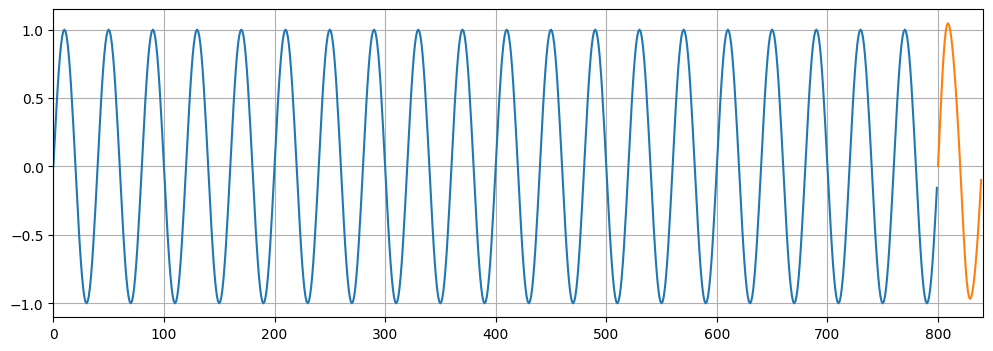

In [16]:
# forecast into an unknown future
preds = y[-window_size:].tolist()
for f in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        model.hidden = (torch.zeros(1,1,model.hidden_size),torch.zeros(1,1,model.hidden_size))
        preds.append(model(seq).item())

plt.figure(figsize=(12,4))
plt.xlim(0,841)
plt.grid(True)
plt.plot(y.numpy())
plt.plot(range(800,800+future),preds[window_size:])
plt.show()
